In [1]:
from dotenv import load_dotenv,find_dotenv
import os
from langchain_openai import AzureChatOpenAI
from langgraph.graph import StateGraph,MessagesState,START,END,add_messages
from langchain_core.messages import HumanMessage,AIMessage
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image
from langgraph.types import Command
from typing import TypedDict, Annotated

load_dotenv(find_dotenv(),override=True)

endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
subscription_key = os.getenv("AZURE_OPENAI_API_KEY")
api_version="2025-01-01-preview"

llm = AzureChatOpenAI(azure_endpoint=endpoint,api_key=subscription_key, api_version=api_version )
GENERATE_POST="generate_post"   
POST="post"
COLLECT_FEEDBACK="collect_feedback"
REVIEW_DECISION="review_decision"

class State(TypedDict): 
    messages: Annotated[list,add_messages]

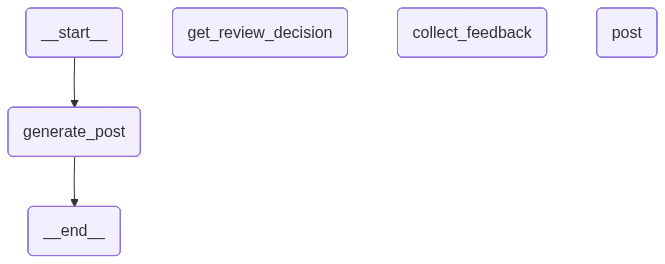

In [2]:
GENERATE_POST = "generate_post"
GET_REVIEW_DECISION = "get_review_decision"
POST = "post"
COLLECT_FEEDBACK = "collect_feedback"

def generate_post(state: State): 
    return {
        "messages": [llm.invoke(state["messages"])]
    }

def get_review_decision(state: State):  
    post_content = state["messages"][-1].content 
    
    print("\n📢 Current LinkedIn Post:\n")
    print(post_content)
    print("\n")

    decision = input("Post to LinkedIn? (yes/no): ")

    if decision.lower() == "yes":
        return POST
    else:
        return COLLECT_FEEDBACK


def post(state: State):  
    final_post = state["messages"][-1].content  
    print("\n📢 Final LinkedIn Post:\n")
    print(final_post)
    print("\n✅ Post has been approved and is now live on LinkedIn!")

def collect_feedback(state: State):  
    feedback = input("How can I improve this post?")
    return {
        "messages": [HumanMessage(content=feedback)]
    }

graph = StateGraph(State)

graph.add_node(GENERATE_POST, generate_post)
graph.add_node(GET_REVIEW_DECISION, get_review_decision)
graph.add_node(COLLECT_FEEDBACK, collect_feedback)
graph.add_node(POST, post)

graph.set_entry_point(GENERATE_POST)

graph.add_conditional_edges(GENERATE_POST, get_review_decision)
graph.add_edge(POST, END)
graph.add_edge(COLLECT_FEEDBACK, GENERATE_POST)

app = graph.compile()
Image(app.get_graph().draw_mermaid_png())

# response = app.invoke({
#     "messages": [HumanMessage(content="Write me a LinkedIn post on AI Agents taking over content creation")]
# })

# print(response)